In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
df = pd.read_excel('Data/cleaned_dataset.xlsx')


In [3]:
df.describe()

,OrderID,Date,Year,Month,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,TotalPrice
count,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.000000,1200.000000
mean,200599.500000,2024-03-22 16:58:48,2023.767500,5.995000,53895.505833,2.945833,356.412750,561.195833,5.554376e+07,5.485000,1053.968300
min,200000.000000,2023-01-01 00:00:00,2023.000000,1.000000,10002.000000,1.000000,11.390000,100.000000,1.000302e+07,1.000000,11.390000
25%,200299.750000,2023-08-03 18:00:00,2023.000000,3.000000,30872.750000,2.000000,186.062500,326.750000,3.294870e+07,4.000000,410.520000
50%,200599.500000,2024-03-23 00:00:00,2024.000000,6.000000,53142.500000,3.000000,364.210000,562.500000,5.609058e+07,5.000000,823.615000
75%,200899.250000,2024-11-08 12:00:00,2024.000000,9.000000,76434.750000,4.000000,521.570000,803.250000,7.767798e+07,7.000000,1578.475000
max,201199.000000,2025-06-30 00:00:00,2025.000000,12.000000,99904.000000,5.000000,699.930000,999.000000,9.998534e+07,10.000000,3456.400000
std,346.554469,NaN,0.750942,3.344293,26303.587100,1.407557,197.177146,267.464995,2.599001e+07,2.281983,819.856558


In [4]:
print(df[df['UnitPrice'] == df['UnitPrice'].min()])
print(df[df['TotalPrice'] == df['TotalPrice'].max()])

      OrderID       Date  Year  Month  CustomerID Product  Quantity  \
1161   201161 2023-10-16  2023     10       32570   Phone         1   

      UnitPrice  ShippingAddress PaymentMethod OrderStatus  TrackingNumber  \
1161      11.39              826          Cash   Cancelled        35969968   

      ItemsInCart CouponCode ReferralSource  TotalPrice  
1161            6   WINTER15          Email       11.39  
     OrderID       Date  Year  Month  CustomerID Product  Quantity  UnitPrice  \
789   200789 2023-08-17  2023      8       57276  Tablet         5     691.28   

     ShippingAddress PaymentMethod OrderStatus  TrackingNumber  ItemsInCart  \
789              183        Online   Delivered        75899752           10   

    CouponCode ReferralSource  TotalPrice  
789     SAVE10          Email      3456.4  


Visualization

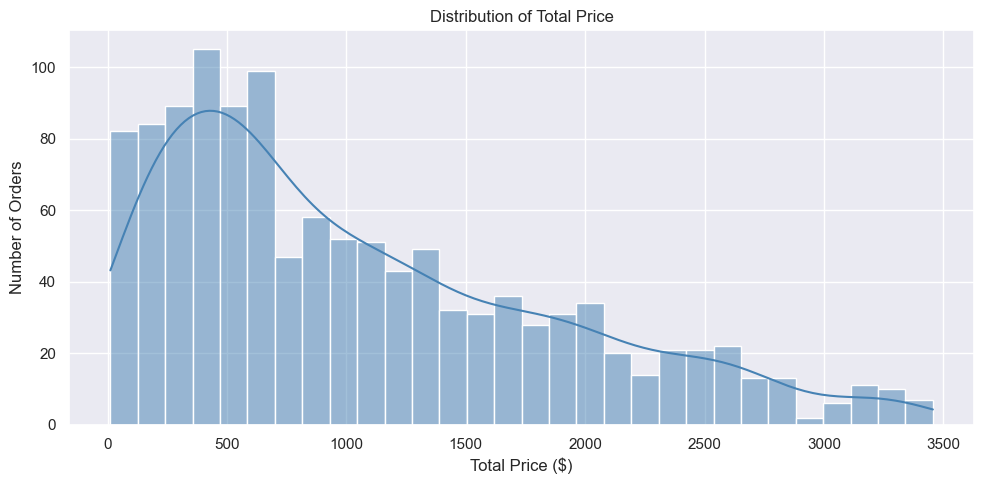

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['TotalPrice'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Total Price')
plt.xlabel('Total Price ($)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

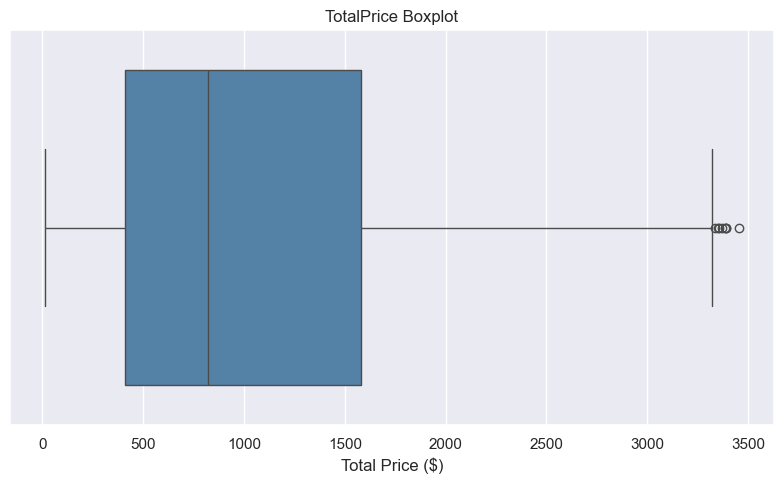

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['TotalPrice'], color='steelblue')
plt.title('TotalPrice Boxplot')
plt.xlabel('Total Price ($)')
plt.tight_layout()
plt.show()

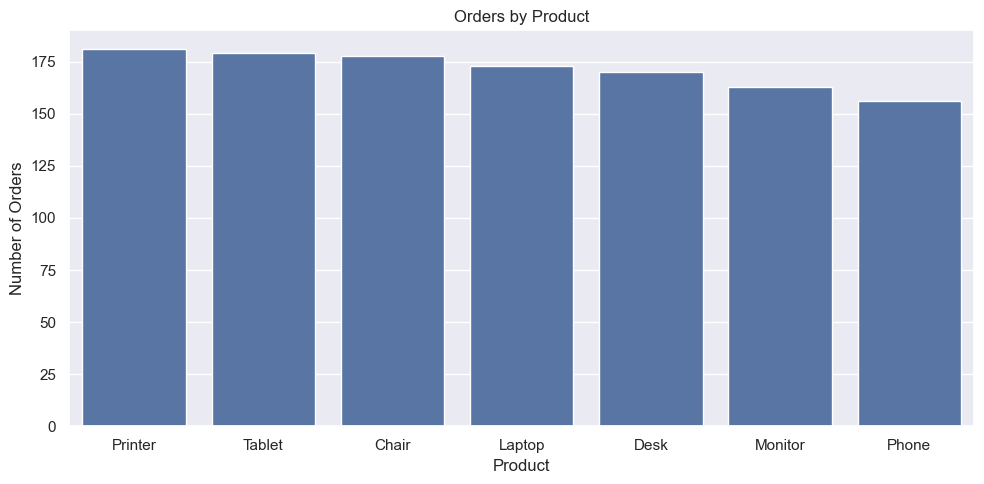

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Product', order=df['Product'].value_counts().index)
plt.title('Orders by Product')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

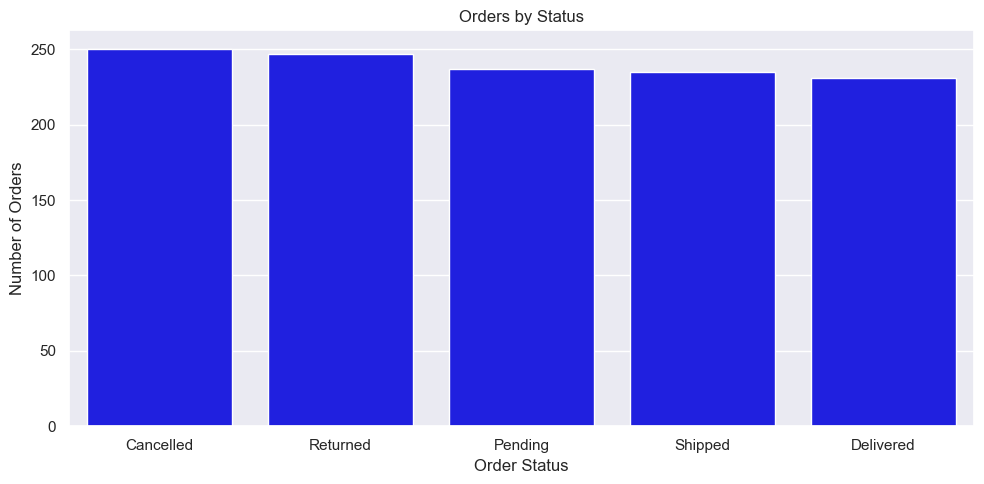

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='OrderStatus', order=df['OrderStatus'].value_counts().index, color='blue')
plt.title('Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

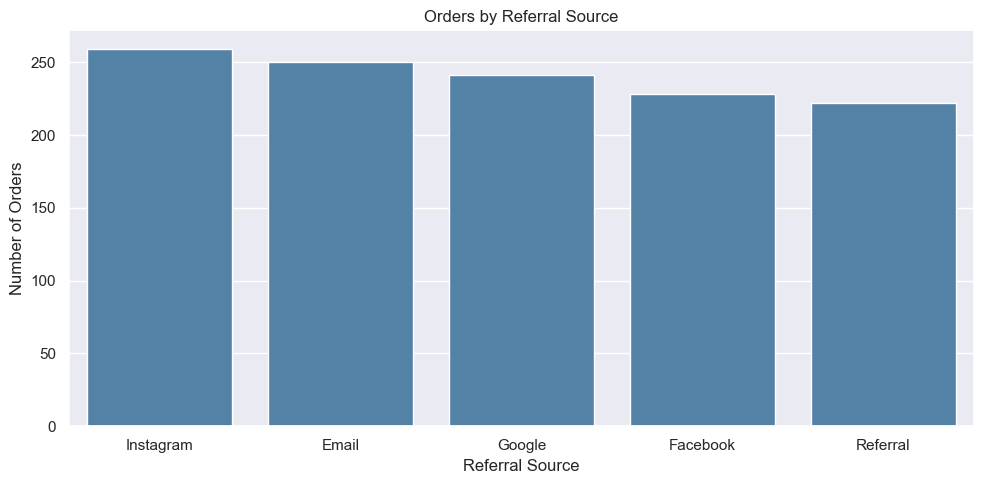

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ReferralSource', order=df['ReferralSource'].value_counts().index, color='steelblue')
plt.title('Orders by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

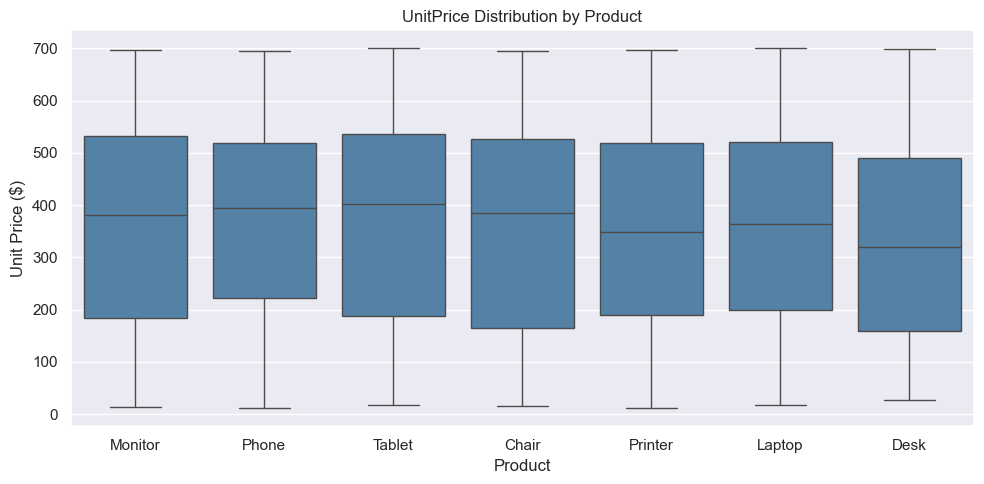

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Product', y='UnitPrice', color='steelblue')
plt.title('UnitPrice Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Unit Price ($)')
plt.tight_layout()
plt.show()

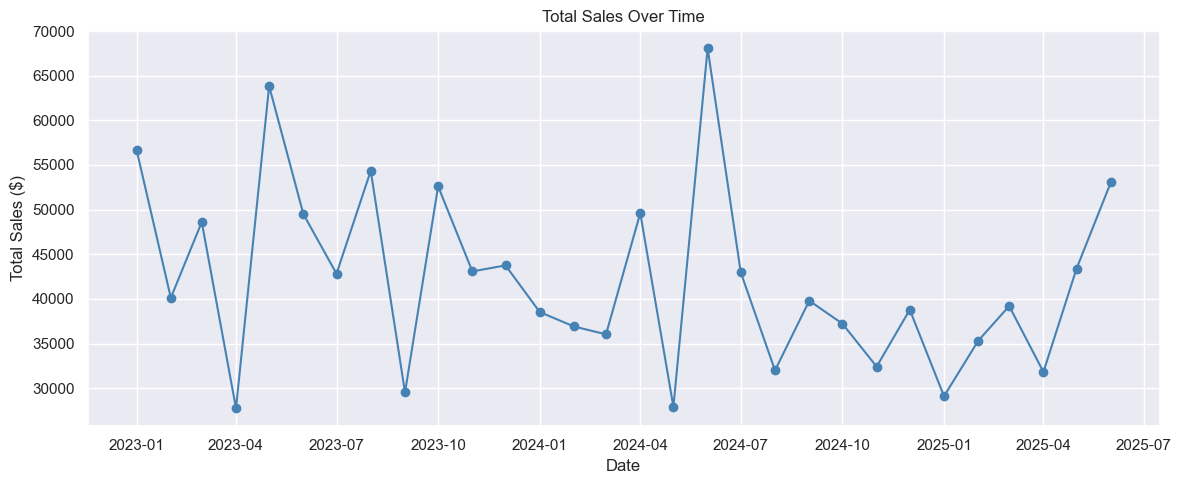

In [11]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Date'], monthly_sales['TotalPrice'], color='steelblue', marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

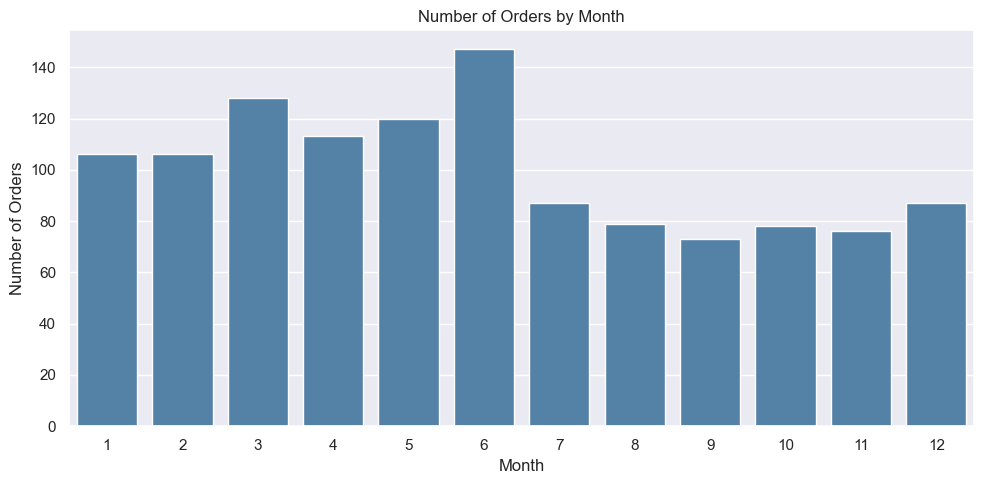

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Month', color='steelblue')
plt.title('Number of Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()